

<font size = "5"> **Chapter 4: [Spectroscopy](CH4_00-Spectroscopy.ipynb)** </font>

<hr style="height:1px;border-top:4px solid #FF8200" />



# Introduction to Core-Loss Spectroscopy
<font size = "5">Working with X-Sections</font>

[Download](https://raw.githubusercontent.com/gduscher/MSE672-Introduction-to-TEM/main/Spectroscopy/CH4_07-Introduction_Core_Loss.ipynb)
 
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
    https://colab.research.google.com/github/gduscher/MSE672-Introduction-to-TEM/blob/main/Spectroscopy/CH4_07-Introduction_Core_Loss.ipynb)


part of 

<font size = "5"> **[MSE672:  Introduction to Transmission Electron Microscopy](../_MSE672_Intro_TEM.ipynb)**</font>

**Spring 2026**<br>
by Gerd Duscher

Microscopy Facilities<br>
Institute of Advanced Materials & Manufacturing<br>
Materials Science & Engineering<br>
The University of Tennessee, Knoxville

Background and methods to analysis and quantification of data acquired with transmission electron microscopes.

## Core --Loss Spectroscopy

As we can see in figure below the energies of the core shells are well defined and can be viewed as delta functions, unlike in the low loss region where the broad valence bands are the initial state. In both cases, however, we excite electrons into the conduction band.

<img title="core-loss" width="50%" alt="core-loss" src="images/core-loss.jpg">
*Excitation from a core-shell state up into the conduction band above the Fermi level.*

If we look at the transition between two states $< \Phi_f | H | \Phi_i >$ the transition should be quite sharp. In the case of the low-loss spectrum, we have many initial (the valence) states and many final (the conduction) states. The spectrum will be a convolution of these states. 

The features of the core--loss edges are, therefore, much sharper than any details in the low--loss region. Because only the final states contribute to the features. These sharp features enable a wide variety of analysis to determine the chemical compositions and chemical bonding, probing the local conduction band of the sample.



### Chemical Composition

In this chapter we use the area under the ionization edge to determine the chemical composition of a (small) sample volume. 
The equation used to determine the number of atoms per unit volume $N$ (also called areal density) is:
\begin{equation}
I_{edge}(\beta, \Delta E) = N I_{0}(\beta) \sigma_{edge}(\beta, \Delta E)
\end{equation}

$I_0$ is the number of electrons hitting the sample, and so directly comparable to the beam current.

The equation can be approximated assuming that the spectrum has not been corrected for single scattering:
\begin{equation} 
I_{edge}(\beta, \Delta E) = N I_{low-loss}(\beta,\Delta E) \sigma_{edge}(\beta, \Delta E)
\end{equation}
where $\beta$ is the collection angle and $\sigma_{edge}$ is the **partial** cross--section (for energy window $\Delta E$) for the core--loss excitation.


> 
> It is this cross-section $ \sigma_{edge}$ that we want to explorein this notebook.
>
We will do the chemical composition in the [next notebook](CH4_08-Chemical_Composition.ipynb)



## Load important packages

### Check Installed Packages


In [ ]:
import sys
import importlib.metadata
def test_package(package_name):
    """Test if package exists and returns version or -1"""
    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = '-1'
    return version

if test_package('pyTEMlib') < '0.2026.1.0':
    print('installing pyTEMlib')
    !{sys.executable} -m pip install  --upgrade pyTEMlib -q

print('done')

### Import all relevant libraries

Please note that the EELS_tools package from pyTEMlib is essential.

In [15]:
%matplotlib ipympl
import sys

import matplotlib
import matplotlib.pylab as plt
import numpy as np

if 'google.colab' in sys.modules:    
    from google.colab import output
    from google.colab import drive
    output.enable_custom_widget_manager()
    
## import the configuration files of pyTEMlib (we need access to the data folder)
import pyTEMlib

# For archiving reasons it is a good idea to print the version numbers out at this point
print('pyTEM version: ',pyTEMlib.__version__)

pyTEM version:  0.2026.1.3


## Load Cross-Sections


The form factors are from:
X-Ray Form Factor, Attenuation, and Scattering Tables
NIST Standard Reference Database 66

 DOI: https://dx.doi.org/10.18434/T4HS32

Detailed Tabulation of Atomic Form Factors, Photoelectric Absorption and Scattering Cross Section, and Mass Attenuation Coefficients for Z = 1-92 from E = 1-10 eV to E = 0.4-1.0 MeV
C.T. Chantler,1 K. Olsen, R.A. Dragoset, J. Chang, A.R. Kishore, S.A. Kotochigova, and D.S. Zucker
NIST, Physical Measurement Laboratory

The cross sections are part of the pyTEMlib package and are stored as a pickled dictionary in the package data directory.

Below are the lines for accessing the cross sections with eels_tools of pyTEMlib.

In [16]:
all_cross_sections = pyTEMlib.eels_tools.get_x_sections()

## Plot Cross Sections

Please add your favourite element ot the list of atomic numbers.

With the code cell above we made the whole database of cross secitons available for this notebook.

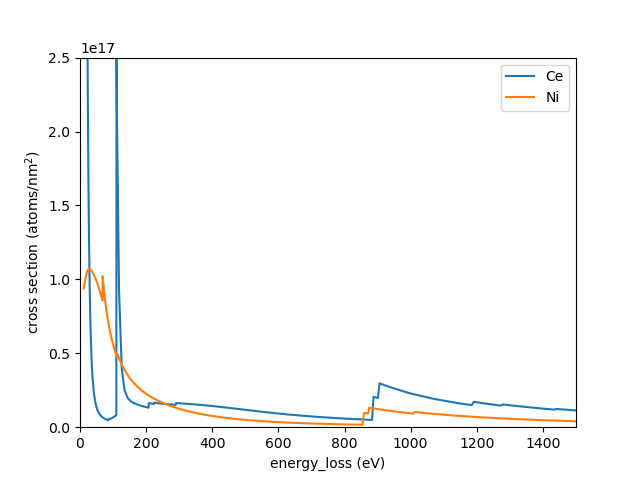

In [19]:
all_cross_sections = pyTEMlib.eels_tools.get_x_sections()
# -----Input ------------ #
atomic_numbers = [58, 28]
# ----------------------- #
fig, ax = plt.subplots()
for Z in atomic_numbers:
    ax.plot(all_cross_sections[str(Z)]['ene'], all_cross_sections[str(Z)]['dat'], label = all_cross_sections[str(Z)]['name'])

ax.set_xlim(0,1500)
ax.set_ylim(0,2.5e17)
ax.set_xlabel('energy_loss (eV)')
ax.set_ylabel('cross section (atoms/nm$^2$)')
plt.legend();

### List All Edges of an Element 

In [20]:
element = str(58)
for key in all_cross_sections[element]:
    if isinstance(all_cross_sections[element][key], dict):
        if 'onset' in all_cross_sections[element][key]:
            print(f"{all_cross_sections[element]['name']}-{key}: {all_cross_sections[element][key]['onset']:8.1f} eV ")
            


Ce-O3:     19.8 eV 
Ce-O2:     19.8 eV 
Ce-O1:     37.8 eV 
Ce-N6:     85.9 eV 
Ce-N5:    110.0 eV 
Ce-N4:    110.0 eV 
Ce-N3:    207.2 eV 
Ce-N2:    223.3 eV 
Ce-N1:    289.6 eV 
Ce-M5:    883.3 eV 
Ce-M4:    901.3 eV 
Ce-M3:   1185.4 eV 
Ce-M2:   1272.8 eV 
Ce-M1:   1434.6 eV 
Ce-L3:   5723.4 eV 
Ce-L2:   6164.2 eV 
Ce-L1:   6548.8 eV 
Ce-K1:  40443.0 eV 


Or ordered

In [23]:
major_edges = ['K1', 'L3', 'M5', 'N5']
all_edges = ['K1','L1','L2','L3','M1','M2','M3','M4','M5','N1', 'N2','N3','N4','N5','N6','N7','O1','O2','O3','O4','O5','O6','O7', 'P1', 'P2', 'P3']
first_close_edges = ['K1', 'L3', 'M5', 'M3', 'N5', 'N3']

element = str(28)

def list_all_edges(Z):
    element = str(Z)
    print('All edges')
    for key in all_edges:
        if key in all_cross_sections[element]:
            if 'onset' in all_cross_sections[element][key]:
                print(f" {all_cross_sections[element]['name']}-{key}: {all_cross_sections[element][key]['onset']:8.1f} eV ")

def list_major_edges(Z):
    element = str(Z)
    print('Major edges')
    for key in major_edges:
        if key in all_cross_sections[element]:
            if 'onset' in all_cross_sections[element][key]:
                print(f" {all_cross_sections[element]['name']}-{key}: {all_cross_sections[element][key]['onset']:8.1f} eV ")                      
## Here with the function of the EELS_tools package                      
list_all_edges(element)
list_major_edges(element)

All edges
 Ni-K1:   8332.8 eV 
 Ni-L1:   1008.1 eV 
 Ni-L2:    871.9 eV 
 Ni-L3:    854.7 eV 
 Ni-M1:    111.8 eV 
 Ni-M2:     68.1 eV 
 Ni-M3:     68.1 eV 
 Ni-M4:      3.6 eV 
 Ni-M5:      3.6 eV 
Major edges
 Ni-K1:   8332.8 eV 
 Ni-L3:    854.7 eV 
 Ni-M5:      3.6 eV 


### Plotting all edges of an element in view

Now, let's do it graphically

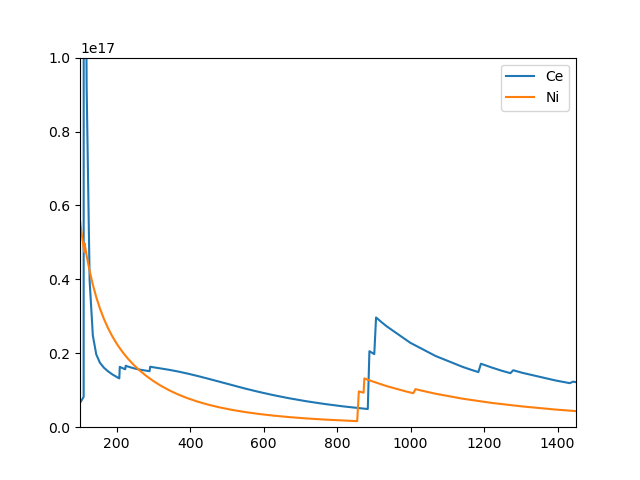

In [24]:
major_edges = ['K1', 'L3', 'M5', 'N5']
all_edges = ['K1','L1','L2','L3','M1','M2','M3','M4','M5','N1', 'N2','N3','N4','N5','N6','N7','O1','O2','O3','O4','O5','O6','O7', 'P1', 'P2', 'P3']
first_close_edges = ['K1', 'L3', 'M5', 'M3', 'N5', 'N3']

def get_Z(Z):
    """
    returns the atomic number independent of input as a string or number
    
    input:
    Z: atomic number of chemical symbol (0 if not valid)
    """
    all_cross_sections = pyTEMlib.eels_tools.get_x_sections()
    
    Z_out = 0
    if str(Z).isdigit(): 
        Z_out = Z
    elif isinstance(Z, str):
        for key in all_cross_sections:
            if all_cross_sections[key]['name'].lower() == Z.lower(): ## Well one really should know how to write elemental 
                Z_out = int(key)
    return Z_out


class ElementalEdges(object):
    def __init__(self, ax, Z):
        self.ax = ax
        self.labels = None
        self.lines = None
        
        self.Z = get_Z(Z)
        self.color = 'black'
        self.Xsections = pyTEMlib.eels_tools.get_x_sections()
        self.cid = ax.figure.canvas.mpl_connect('draw_event', self.onresize)
        
        #self.update()
    def set_edge(self,Z):
        self.Z = get_Z(Z)
        
            
        self.update()
    def onresize(self, event):
        self.update()
        
    def update(self):
        
        if self.labels != None:
            for label in self.labels:
                label.remove()
        if self.lines != None:
            for line in self.lines:
                line.remove()
        if self.Z>0:
            self.labels = [] ; self.lines =[] 
            x_min, x_max = self.ax.get_xlim()
            y_min, y_max = self.ax.get_ylim()
            x_bounds = ax.get_xlim()
            element = str(self.Z)
            Xsections = self.Xsections
            for key in all_edges:
                if key in Xsections[element]:
                    if 'onset' in Xsections[element][key]:
                        x = Xsections[element][key]['onset']
                        if x > x_min and x < x_max:
                            if key in first_close_edges:
                                label2 = self.ax.text(x, y_max,f"{Xsections[element]['name']}-{key}",
                                                      verticalalignment='top', rotation = 0, color = self.color)
                            else:
                                label2 = self.ax.text(x, y_max,f"\n{Xsections[element]['name']}-{key}",
                                                      verticalalignment='top', color = self.color)
                            line2 = self.ax.axvline(x,ymin = 0,ymax = 1,color=self.color)

                            self.labels.append(label2)

                            self.lines.append(line2)
                    
        
    def disconnect(self):
        if self.labels != None:
            for label in self.labels:
                label.remove()
        if self.lines != None:
            for line in self.lines:
                line.remove()
        self.labels = None
        self.lines = None
        self.ax.figure.canvas.mpl_disconnect(self.cid)
    def reconnect(self):    
        self.cid = ax.figure.canvas.mpl_connect('draw_event', self.onresize)
        ax.figure.canvas.draw_idle()
        
fig, ax_Xsec = plt.subplots()                
for Z in atomic_numbers:
    ax_Xsec.plot(all_cross_sections[str(Z)]['ene'], all_cross_sections[str(Z)]['dat'], label = all_cross_sections[str(Z)]['name'])
ax_Xsec.set_xlim(100,1450)
ax_Xsec.set_ylim(0,1e17)
plt.legend();   
Z = 58
edges = ElementalEdges(ax_Xsec, 'Ce')


Let's make the lines disappear

In [25]:
edges.disconnect()

and reappear in the plot above

In [26]:
edges.set_edge(Z)

Let's set another edge

In [27]:
edges.set_edge(28)

### Find Edges Listed in Xsection Dictionary

please note that the two functions below are as ususal available in the EELS_tools of pyTEMlib

In [30]:
# --- Input ----
edge_onset = 708
maximal_chemical_shift = 7
# -------------
print(f'Major Edges within {maximal_chemical_shift:.1f} eV of {edge_onset:.1f}')
print(pyTEMlib.eels_tools.find_all_edges(edge_onset, maximal_chemical_shift, major_edges_only=True))
print(f'\nAll Edges within {maximal_chemical_shift:.1f} eV of {edge_onset:.1f}')
print(pyTEMlib.eels_tools.find_all_edges(edge_onset, maximal_chemical_shift))

Major Edges within 7.0 eV of 708.0

 Fe-L3:    708.1 eV 

All Edges within 7.0 eV of 708.0

 Fe-L3:    708.1 eV 
 In-M2:    702.2 eV 
 Sn-M3:    714.4 eV 


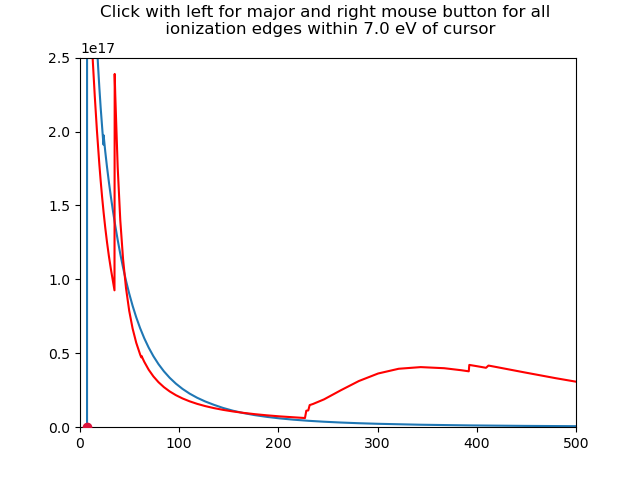

In [31]:
class EdgesAtCursor(object):
    def __init__(self, ax, energy, data, maximal_chemical_shift=5):
        self.ax = ax
        self.maximal_chemical_shift = maximal_chemical_shift
        self.energy = energy
        self.label = None
        self.line = None
        self.marker, = ax.plot(energy[0], data[0], marker="o", color="crimson", zorder=3)
        
        self.cursor = matplotlib.widgets.Cursor(ax, useblit=True, color='blue', linewidth=2, horizOn=False, alpha=.3)
        self.cid = ax.figure.canvas.mpl_connect('button_press_event', self.edges_on_click)
        #self.mouse_cid = ax.figure.canvas.mpl_connect('motion_notify_event', self.mouse_move)
        

    def edges_on_click(self, event):
        if not event.inaxes:
            return
        x= event.xdata
        if self.label is not None:
            self.label.remove()
        if self.line is not None:
            self.line.remove()
        if event.button ==  1:
            self.label = plt.text(x, plt.gca().get_ylim()[1], pyTEMlib.eels_tools.find_all_edges(x, self.maximal_chemical_shift, True),
                                      verticalalignment='top')
        else:
            self.label = plt.text(x, plt.gca().get_ylim()[1], pyTEMlib.eels_tools.find_all_edges(x, self.maximal_chemical_shift),
                                      verticalalignment='top')
        self.line = plt.axvline(x=x, color='gray')

        
fig, ax = plt.subplots()
plt.title(f'Click with left for major and right mouse button for all \n ionization edges within {maximal_chemical_shift:.1f} eV of cursor')

cursor = EdgesAtCursor(ax, all_cross_sections['16']['ene'], all_cross_sections['16']['dat'], 5)
ax.plot(all_cross_sections['16']['ene'], all_cross_sections['16']['dat']*2, label = 'S')
ax.plot(all_cross_sections['42']['ene'], all_cross_sections['42']['dat'], 'r', label = 'Mo')
ax.set_xlim(0,500)
ax.set_ylim(0,2.5e17);
#plt.connect('button_press_event', edges_on_click)

### Find Edges Depending on Cursor Postion

17

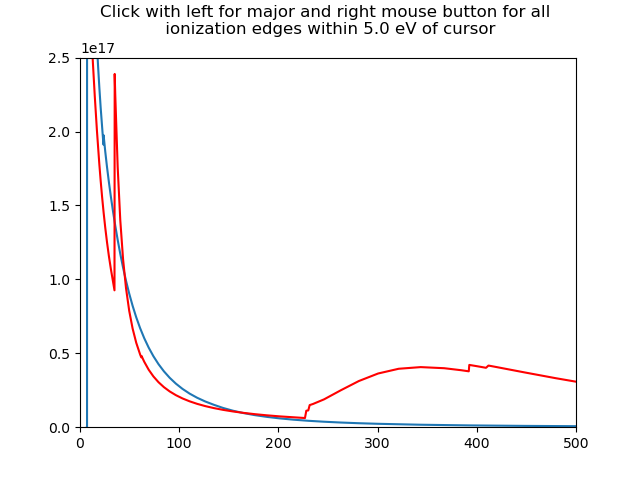

In [32]:
# ------ Input ------
maximal_chemical_shift = 5
# -------------------
label = None
line  = None
def edges_on_click(event):
    global maximal_chemical_shift
    global line, label
    if not event.inaxes:
        return
    x= event.xdata
    if label is not None:
        label.remove()
    if line is not None:
        line.remove()
    if event.button ==  1:
        label = plt.text(x, plt.gca().get_ylim()[1], pyTEMlib.eels_tools.find_all_edges(x, maximal_chemical_shift, True),
                                  verticalalignment='top')
    else:
        label = plt.text(x, plt.gca().get_ylim()[1], pyTEMlib.eels_tools.find_all_edges(x, maximal_chemical_shift),
                                  verticalalignment='top')
    line = plt.axvline(x=x,  color='gray')

fig, ax = plt.subplots()
plt.title(f'Click with left for major and right mouse button for all \n ionization edges within {maximal_chemical_shift:.1f} eV of cursor')

cursor = matplotlib.widgets.Cursor(ax, useblit=True, color='blue', linewidth=2, horizOn=False, alpha=.3)
ax.plot(all_cross_sections['16']['ene'], all_cross_sections['16']['dat']*2, label = 'S')
ax.plot(all_cross_sections['42']['ene'], all_cross_sections['42']['dat'], 'r', label = 'Mo')
ax.set_xlim(0,500)
ax.set_ylim(0,2.5e17);
plt.connect('button_press_event', edges_on_click)


## EELS cross sections
### Determine Effective Collection Angle

EELS cross sections are dependent on the momentum transfer (angle dependence), while photons cannot transfer any momentum. The angle dependence is given by the experimental set-up and can be calculated by the convolution of collection and convergence angle.

Here we use the method of [Pierre Trebbia, Ultramicroscopy **24** (1988) pp.399-408](https://doi.org/10.1016/0304-3991(88)90130-1)


In [33]:
def effective_collection_angle(ene,  alpha, beta, beam_kv):
    """ effective collection angle for convergent beam setup
    
    
    
    Original abstract of function y = effbeta(ene,  alpha, beta, beamkV)
    # 
    #       This program computes etha(alpha,beta), that is the collection
    #       efficiency associated to the following geometry :
    #
    #       alpha = half angle of illumination  (0 -> pi/2)
    #       beta  = half angle of collection    (0 -> pi/2)
    #                                           (pi/2 = 1570.795 mrad)
    #
    #           A constant angular distribution of incident electrons is assumed
    #       for any incident angle (-alpha,alpha). These electrons impige the
    #       target and a single energy loss event occurs, with a characteristic
    #       angle theta-e (relativistic). The angular distribution of the
    #       electrons after the target is analytically derived.
    #           This program integrates this distribution from theta=0 up to
    #       theta=beta with an adjustable angular step.
    #           This program also computes beta* which is the theoretical
    #       collection angle which would give the same value of etha(alpha,beta)
    #       with a parallel incident beam.
    #
    #       subroutines and function subprograms required
    #       ---------------------------------------------
    #       none
    #
    #       comments
    #       --------
    #
    #       The following parameters are asked as input :
    #        accelerating voltage (kV), energy loss range (eV) for the study,
    #        energy loss step (eV) in this range, alpha (mrad), beta (mrad).
    #       The program returns for each energy loss step :
    #        alpha (mrad), beta (mrad), theta-e (relativistic) (mrad),
    #        energy loss (eV), etha (#), beta * (mrad)
    #
    #       author :
    #       --------
    #       Pierre TREBBIA
    #       US 41 : "Microscopie Electronique Analytique Quantitative"
    #       Laboratoire de Physique des Solides, Bat. 510
    #       Universite Paris-Sud, F91405 ORSAY Cedex
    #       Phone : (33-1) 69 41 53 68
    #
    #       
    """
        
       
    z1 = beam_kv*1000.  ;   # eV
    z2 = ene[0];
    z3 = ene[-1]
    z4 = 100.0
    z5 = alpha*0.001   # rad
    z6 = beta*0.001    # rad
    z7 = 500          # number of integration steps to be modified at will

    # main loop on energy loss
    
    for  zx in range(int(z2),int(z3),int(z4)): #! zx = current energy loss
        eta=0.0;
        x0=float(zx)*(z1+511060.)/(z1*(z1+1022120.));  # x0 = relativistic theta-e
        x1 = np.pi/(2.*x0);
        x2=x0*x0+z5*z5;
        x3=z5/x0*z5/x0;
        x4=0.1*np.sqrt(x2);
        dtheta=(z6-x4)/z7;
        #
        # calculation of the analytical expression
        #
        for zi in range(1, int(z7)):
            theta=x4+dtheta*float(zi);
            x5=theta*theta;
            x6=4.*x5*x0*x0;
            x7=x2-x5;
            x8=np.sqrt(x7*x7+x6);
            x9=(x8+x7)/(2.*x0*x0);
            x10=2.*theta*dtheta*np.log(x9);
            eta=eta+x10;
    
              
    
        eta=eta+x2/100.*np.log(1.+x3)   ;  # addition of the central contribution
        x4=z5*z5*np.log(1.+x1*x1);         # normalisation
        eta=eta/x4;
        #
        #        correction by geometrical factor (beta/alpha)**2
        #
        if (z6<z5):
            x5=z5/z6;
            eta=eta*x5*x5;
    
        etha2=eta*100.;
        #
        #        calculation of beta *
        #
        x6=np.power((1.+x1*x1),eta);
        x7=x0*np.sqrt(x6-1.);
        y=x7*1000.;

    
    return y

    

In [34]:
# --- Input -----------
alpha=30 
beta=40
# --------------------
energy_scale = np.linspace(100,500,1000)

eff_beta = effective_collection_angle(energy_scale,  alpha=alpha, beta=beta, beam_kv=200)
print(f'Convergence angle  {alpha:.2f} mrad and collection angle {beta:.2f} mrad \n '
      f'results in effective collection angle of is {eff_beta:.2f} mrad')

Convergence angle  30.00 mrad and collection angle 40.00 mrad 
 results in effective collection angle of is 33.40 mrad


### Calculating EELS Cross Section

EELS cross sections are dependent on the momentum transfer (angle dependence), while photons cannot transfer any momentum. The angle dependence of the cross-section is aproximated by the equation 4 in:
[Egerton Ultramicroscopy 50 (1993) 13-28](https://doi.org/10.1016/0304-3991(93)90087-E)

The units of atom density in  electron microscopy is atoms per nm$^2$.
Cross sections are normally given in barns (a neutron scattering joke).

A barn is 10$^{-28}$ m$^2$ which is then 1 barn = 10$^{-10}$ nm$^2$

Therefore, to get a probability per nm$^2$ we have to divide the cross-section in barns by 10$^{10}$

𝐼𝑒𝑑𝑔𝑒(𝛽,Δ𝐸)=𝑁𝐼𝑙𝑜𝑤−𝑙𝑜𝑠𝑠(𝛽,Δ𝐸)𝜎𝑒𝑑𝑔𝑒(𝛽,Δ𝐸)


In [35]:

from scipy.interpolate import splev,splrep,splint
#from scipy.integrate import quad
from scipy.interpolate import interp1d
from scipy.optimize import leastsq

def xsec_xrpa(energy_scale, E0, Z, beta, shift=0 ):
    """
    Calculate momentum-integrated cross-section for EELS from X-ray photoaborption  cross-sections.
    
    Input:
    ------
    energy_scale: energyscale of spectrum to be analyzed
    E0: acceleration voltage in keV
    Z: atomic number of element
    beta: effective collection angle in mrad
    shift: chemical shift of edge in eV
    """
 
    beta = beta * 0.001;     #% collection half angle theta [rad]
    #thetamax = self.parent.spec[0].convAngle * 0.001;  #% collection half angle theta [rad]
    dispersion = energy_scale[1]-energy_scale[0]
    
    Xsections = eels.get_Xsections(Z)
    enexs = Xsections['ene']
    datxs = Xsections['dat']
        
    #####
    ## Cross Section according to Egerton Ultramicroscopy 50 (1993) 13-28 equation (4)
    #####

    # Relativistic correction factors
    T = 511060.0*(1.0-1.0/(1.0+E0/(511.06))**2)/2.0;
    gamma=1+E0/511.06;
    A = 6.5#e-14 *10**14
    b = beta

    thetaE = enexs/(2*gamma*T)

    G = 2*np.log(gamma)-np.log((b**2+thetaE**2)/(b**2+thetaE**2/gamma**2))-(gamma-1)*b**2/(b**2+thetaE**2/gamma**2)
    datxs = datxs*(A/enexs/T)*(np.log(1+b**2/thetaE**2)+G)/1e8

    datxs = datxs * dispersion # from per eV to per dispersion
    coeff = splrep(enexs,datxs,s=0) # now in areal density atoms / m^2
    xsec = np.zeros(len(energy_scale ))
    #shift = 0# int(ek -onsetXRPS)#/dispersion
    lin = interp1d(enexs,datxs,kind='linear') # Linear instead of spline interpolation to avoid oscillations.
    xsec = lin(energy_scale-shift)
    
    return xsec
energy_scale = np.arange(100,600)
B_Xsection = pyTEMlib.eels_tools.xsec_xrpa(energy_scale, 200, 5,  10. )/1e10  
N_Xsection = pyTEMlib.eels_tools.xsec_xrpa(energy_scale, 200, 7,  10. )/1e10       #  xsec  is in barns = 10^28 m2 = 10^10 nm2


### Plotting of Cross Sections
please note that spectrum and cross sections are not on the same scale

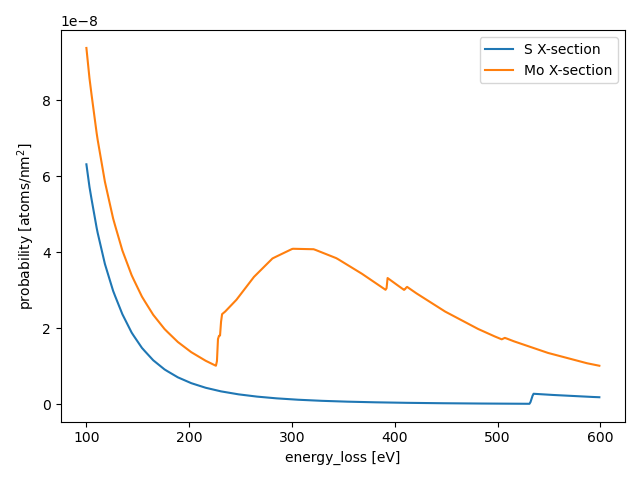

In [36]:
# ----Input ----------
effective_collection_angle = 20
# --------------------

S_Xsection  = pyTEMlib.eels_tools.xsec_xrpa(energy_scale, 200, 16, effective_collection_angle )/1e10  
Mo_Xsection = pyTEMlib.eels_tools.xsec_xrpa(energy_scale, 200, 42, effective_collection_angle, shift=0)/1e10       #  xsec  is in barns = 10^28 m2 = 10^10 nm2

fig, ax1 = plt.subplots()

ax1.plot(energy_scale, S_Xsection, label='S X-section' )
ax1.plot(energy_scale, Mo_Xsection, label='Mo X-section' )
ax1.set_xlabel('energy_loss [eV]')
ax1.set_ylabel('probability [atoms/nm$^{2}$]')


plt.legend();
fig.tight_layout();

## Summary

The cross section is key to determine the chemical composition of an EELS spectrum. 
These cross sections are dependent on:
- acceleration voltage
- effective collection angle
- element

So these experimental parameters have to be provided for a calculations of cross sections.

We will use these cross sections in the [chemical compostions notebook](CH4_08-Chemical_Composition.ipynb)

## Navigation
- <font size = "3">  **Up Chapter 4: [Imaging](CH4_00-Spectroscopy.ipynb)** </font>
- <font size = "3">  **Back: [Dielectric Function](CH4_03-Drude.ipynb)** </font>
- <font size = "3">  **Next: [Chemical Composition](CH4_08-Chemical_Composition.ipynb)** </font>
- <font size = "3">  **List of Content: [Front](../_MSE672_Intro_TEM.ipynb)** </font>
